In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score ,precision_score , recall_score , f1_score
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
import joblib
import warnings
warnings.filterwarnings("ignore")

## Import

In [3]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Explore

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [5]:
df.shape

(10000, 14)

In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
#Cheak high and low cardinality
df.select_dtypes("object").nunique()

Surname      2932
Geography       3
Gender          2
dtype: int64

In [9]:
df.drop(['RowNumber', 'CustomerId', 'Surname'],axis=1,inplace= True)

In [10]:
df = pd.get_dummies(df,drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [11]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

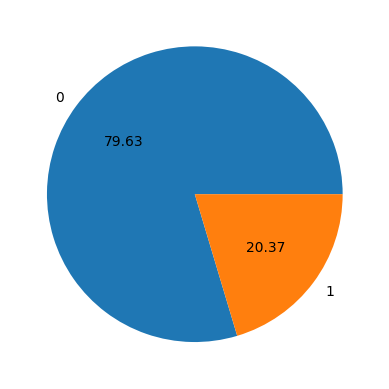

In [12]:
df['Exited'].value_counts().plot.pie(autopct ='%.2f');

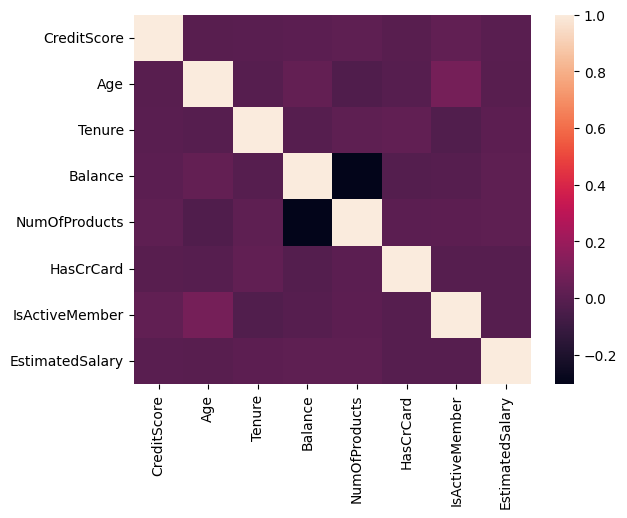

In [13]:
# Check multicollinearity 
correlation = df.select_dtypes("number").drop(columns ="Exited").corr();

sns.heatmap(correlation);

there's no issue with multicollinearity in our dataset.

In [14]:
pivot = pd.pivot_table(df, values=["Age","CreditScore","Balance","NumOfProducts","HasCrCard","IsActiveMember","EstimatedSalary"], index='Exited', aggfunc="mean")
pivot

,Age,Balance,CreditScore,EstimatedSalary,HasCrCard,IsActiveMember,NumOfProducts
Exited,,,,,,,
0,37.408389,72745.296779,651.853196,99738.391772,0.707146,0.554565,1.544267
1,44.837997,91108.539337,645.351497,101465.677531,0.699067,0.360825,1.475209


Customers with higher age, larger balance, and inactive membership are more likely to exit compared to others.

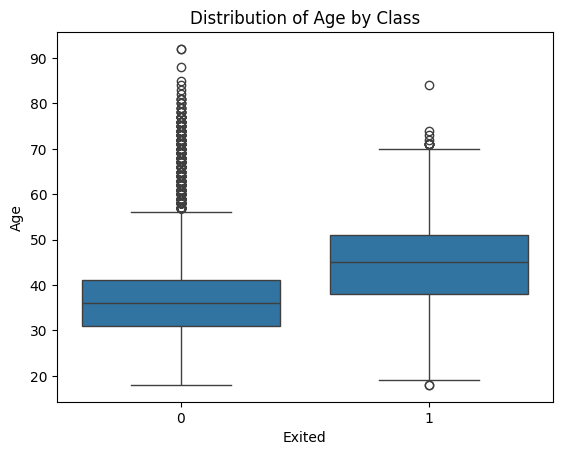

In [15]:
sns.boxplot(x="Exited",y = "Age" , data =df)
# Label axes
plt.xlabel("Exited")
plt.ylabel("Age")
plt.title("Distribution of Age by Class");

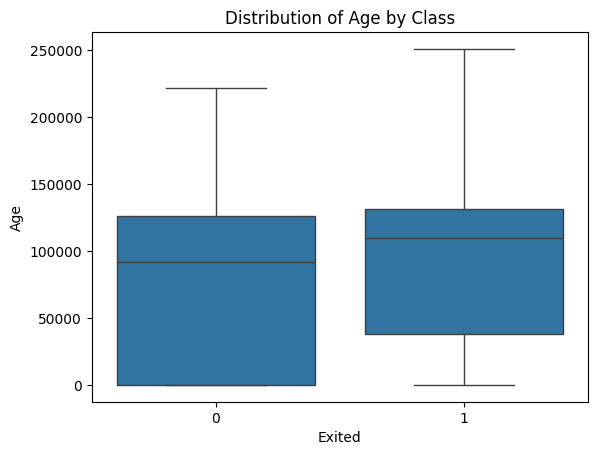

In [16]:
sns.boxplot(x="Exited",y = "Balance" , data =df)
# Label axes
plt.xlabel("Exited")
plt.ylabel("Age")
plt.title("Distribution of Age by Class");

In [17]:
ger_mask = df["Geography_Germany"] == 1
ger = df[ger_mask]
print(f"Exit percentage for Germany = {round(ger["Exited"].sum() / len(ger) *100,2)} %")
spa_mask = df["Geography_Spain"] == 1
spa = df[spa_mask]
print(f"Exit percentage for Spain = {round(spa["Exited"].sum() / len(spa) * 100,2)} %")
fra_mask = ~(ger_mask | spa_mask)
fra = df[fra_mask]
print(f"Exit percentage for France = {round(fra["Exited"].sum() / len(fra) *100 ,2)} %")

Exit percentage for Germany = 32.44 %
Exit percentage for Spain = 16.67 %
Exit percentage for France = 16.15 %


The exit rate of German customers is higher than that of other Spain and France.

## Split

In [18]:
X = df.drop("Exited",axis=1)
y = df["Exited"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)
print(X_train.shape,X_test.shape)

(8000, 11) (2000, 11)


## Feature Scaling

In [20]:
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

## Imbalance Handling

I will use SMOTE technique 

In [21]:
X_res,y_res = SMOTE().fit_resample(X,y)
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(X_res, y_res, test_size=.2, random_state=42, stratify=y_res)
X_train_imb = sc.fit_transform(X_train_imb)
X_test_imb = sc.transform(X_test_imb)

I want to compare the model's accuracy between using raw data, applying scaling, and handling class imbalance, and analyze its impact on distance-based models and tree-based models.

## Logistic Regression

In [22]:
log = LogisticRegression(max_iter=10000)
log.fit(X_train,y_train)
y_pred_log = log.predict(X_test)
print("F1 Score =",round(f1_score(y_test,y_pred_log),3))
print("Accuracy Score =",accuracy_score(y_test,y_pred_log))

log2 = LogisticRegression()
log2.fit(X_train_sc,y_train)
y_pred_sc_log = log2.predict(X_test_sc)
print("F1 Score With Scaling =",round(f1_score(y_test,y_pred_sc_log),3))

log3 = LogisticRegression()
log3.fit(X_train_imb,y_train_imb)
y_pred_imb_log = log3.predict(X_test_imb)
print("F1 Score With Oversampling the Minority Class =",round(f1_score(y_test_imb,y_pred_imb_log),3))

F1 Score = 0.285
Accuracy Score = 0.8095
F1 Score With Scaling = 0.284
F1 Score With Oversampling the Minority Class = 0.768


In [23]:
for i in range(len(y_pred_log)):
    if y_pred_log[i] != y_pred_sc_log[i]:
        print(f"Element Number ({i+1})" ,y_pred_log[i] , y_pred_sc_log[i])

Element Number (93) 0 1
Element Number (112) 1 0
Element Number (436) 0 1
Element Number (888) 1 0
Element Number (952) 0 1
Element Number (1048) 1 0
Element Number (1169) 1 0
Element Number (1181) 1 0
Element Number (1382) 0 1
Element Number (1386) 0 1
Element Number (1668) 0 1
Element Number (1829) 0 1
Element Number (1917) 0 1


In [24]:
log.coef_[0]

array([-1.00667159e-03,  6.87938864e-02, -4.24186234e-03,  2.55014245e-06,
       -1.09791273e-01, -7.33594766e-02, -1.03367641e+00,  7.95186778e-07,
        8.27359431e-01,  3.57180648e-02, -5.13186284e-01])

In [25]:
log2.coef_[0]

array([-0.08598646,  0.73884671, -0.02007121,  0.16062216, -0.07029166,
       -0.03220758, -0.51548506,  0.04772528,  0.35667926,  0.01890713,
       -0.26085102])

In [26]:
log3.coef_[0]

array([-0.09503126,  0.87571439, -0.13817852, -0.0937924 , -0.39993504,
       -0.31704063, -0.85185533,  0.03746225,  0.81230254,  0.34442395,
        0.01407021])

## SVC

In [27]:
model = svm.SVC()
model.fit(X_train,y_train)
y_pred_svc = model.predict(X_test)
print("F1 Score =",round(f1_score(y_test,y_pred_svc),3))
print("Accuracy Score =",accuracy_score(y_test,y_pred_svc))

model.fit(X_train_sc,y_train)
y_pred_sc_svc = model.predict(X_test_sc)
print("F1 Score With Scaling =",round(f1_score(y_test,y_pred_sc_svc),3))

model.fit(X_train_imb,y_train_imb)
y_pred_imb_svc = model.predict(X_test_imb)
print("F1 Score With Oversampling the Minority Class =",round(f1_score(y_test_imb,y_pred_imb_svc),3))

F1 Score = 0.0
Accuracy Score = 0.7965
F1 Score With Scaling = 0.537
F1 Score With Oversampling the Minority Class = 0.829


## KNeighbors Classifier

In [28]:
model = KNeighborsClassifier()
model.fit(X_train,y_train)
y_pred_kn = model.predict(X_test)
print("F1 Score =",round(f1_score(y_test,y_pred_kn),3))
print("Accuracy Score =",accuracy_score(y_test,y_pred_kn))


model.fit(X_train_sc,y_train)
y_pred_sc_kn = model.predict(X_test_sc)
print("F1 Score With Scaling =",round(f1_score(y_test,y_pred_sc_kn),3))

model.fit(X_train_imb,y_train_imb)
y_pred_imb_kn = model.predict(X_test_imb)
print("F1 Score With Oversampling the Minority Class =",round(f1_score(y_test_imb,y_pred_imb_kn),3))

F1 Score = 0.126
Accuracy Score = 0.764
F1 Score With Scaling = 0.443
F1 Score With Oversampling the Minority Class = 0.822


## Decision Tree

In [29]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred_dt = model.predict(X_test)
print("F1 Score =",round(f1_score(y_test,y_pred_dt),3))
print("Accuracy Score =",accuracy_score(y_test,y_pred_dt))


model.fit(X_train_sc,y_train)
y_pred_sc_dt = model.predict(X_test_sc)
print("F1 Score With Scaling =",round(f1_score(y_test,y_pred_sc_dt),3))

model.fit(X_train_imb,y_train_imb)
y_pred_imb_dt = model.predict(X_test_imb)
print("F1 Score With Oversampling the Minority Class =",round(f1_score(y_test_imb,y_pred_imb_dt),3))

F1 Score = 0.494
Accuracy Score = 0.787
F1 Score With Scaling = 0.489
F1 Score With Oversampling the Minority Class = 0.802


## Random Forest

In [30]:
model = RandomForestClassifier()
model.fit(X_train,y_train)
y_pred_rf = model.predict(X_test)
print("F1 Score =",round(f1_score(y_test,y_pred_rf),3))
print("Accuracy Score =",accuracy_score(y_test,y_pred_rf))


model.fit(X_train_sc,y_train)
y_pred_sc_rf = model.predict(X_test_sc)
print("F1 Score With Scaling =",round(f1_score(y_test,y_pred_sc_rf),3))

model.fit(X_train_imb,y_train_imb)
y_pred_imb_rf = model.predict(X_test_imb)
print("F1 Score With Oversampling the Minority Class =",round(f1_score(y_test_imb,y_pred_imb_rf),3))

F1 Score = 0.584
Accuracy Score = 0.866
F1 Score With Scaling = 0.583
F1 Score With Oversampling the Minority Class = 0.861


## Gradient Boosting

In [31]:
model = GradientBoostingClassifier()
model.fit(X_train,y_train)
y_pred_gb = model.predict(X_test)
print("F1 Score =",round(f1_score(y_test,y_pred_gb),3))
print("Accuracy Score =",accuracy_score(y_test,y_pred_gb))


model.fit(X_train_sc,y_train)
y_pred_sc_gb = model.predict(X_test_sc)
print("F1 Score With Scaling =",round(f1_score(y_test,y_pred_sc_gb),3))

model.fit(X_train_imb,y_train_imb)
y_pred_imb_gb = model.predict(X_test_imb)
print("F1 Score With Oversampling the Minority Class =",round(f1_score(y_test_imb,y_pred_imb_gb),3))

F1 Score = 0.605
Accuracy Score = 0.87
F1 Score With Scaling = 0.605
F1 Score With Oversampling the Minority Class = 0.831


Scaling has no impact on tree-based models, while handling imbalance is significantly important for all models.

## Evaluate

In [32]:
acc_dic = {'Model':["LogisticRegression","SVC","KNeighbors Classifier","Decision Tree","Random Forest","Gradient Boosting"] ,
      "Accurcy Score After Oversampling": [accuracy_score(y_test_imb,y_pred_imb_log),accuracy_score(y_test_imb,y_pred_imb_svc),accuracy_score(y_test_imb,y_pred_imb_kn),accuracy_score(y_test_imb,y_pred_imb_dt),accuracy_score(y_test_imb,y_pred_imb_rf),accuracy_score(y_test_imb,y_pred_imb_gb)],     
      "F1 Score After Oversampling": [f1_score(y_test_imb,y_pred_imb_log),f1_score(y_test_imb,y_pred_imb_svc),f1_score(y_test_imb,y_pred_imb_kn),f1_score(y_test_imb,y_pred_imb_dt),f1_score(y_test_imb,y_pred_imb_rf),f1_score(y_test_imb,y_pred_imb_gb)]
      }
evaluate = pd.DataFrame(acc_dic)
evaluate = evaluate.set_index("Model")

In [33]:
evaluate.sort_values(by="F1 Score After Oversampling" , ascending=False)

,Accurcy Score After Oversampling,F1 Score After Oversampling
Model,,
Random Forest,0.862837,0.861049
Gradient Boosting,0.833333,0.830622
SVC,0.833019,0.829487
KNeighbors Classifier,0.820465,0.822250
Decision Tree,0.799121,0.801612
LogisticRegression,0.769931,0.767965


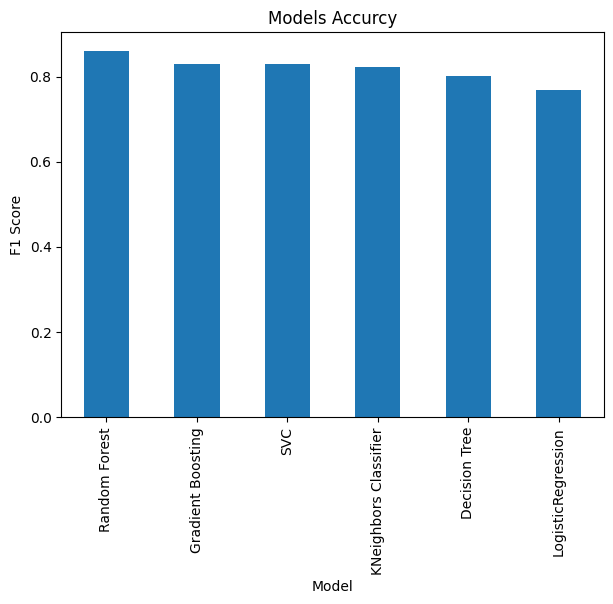

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))
evaluate["F1 Score After Oversampling"].sort_values( ascending=False).plot.bar(ax=ax)
plt.ylabel("F1 Score")
plt.title("Models Accurcy");

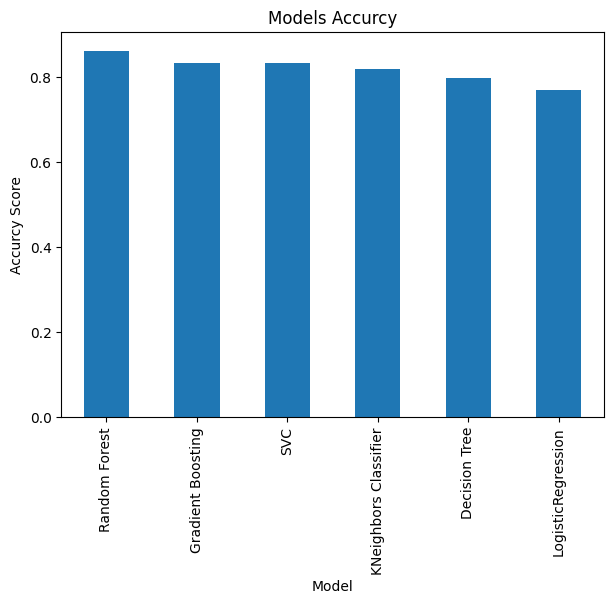

In [35]:
fig, ax = plt.subplots(figsize=(7, 5))
evaluate["Accurcy Score After Oversampling"].sort_values( ascending=False).plot.bar(ax=ax)
plt.ylabel("Accurcy Score")
plt.title("Models Accurcy");

# Communicate

In [36]:
rf = RandomForestClassifier()
rf.fit(X_train_imb,y_train_imb)
joblib.dump(rf,"app.pki")

['app.pki']

In [37]:
rf_model = joblib.load("app.pki")

In [38]:
df.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='str')

In [39]:
def willExit(cscore,age,tenure,balance,numofprodeuct,hascard,active,salary,germany,spain,male):
    will_exit =  rf_model.predict([[cscore,age,tenure,balance,numofprodeuct,hascard,active,salary,germany,spain,male]])[0]
    print("The customer Will Leave the Bank" if will_exit == 1 else "The customer Will not Leave the Bank" )    

In [40]:
willExit(650,42,2,2000,4,0,1,5000,0,1,0)


The customer Will Leave the Bank


In [41]:
willExit(619,42,2,0,0,0,0,101348.88,0,1,0)


The customer Will Leave the Bank


Trying the same data by changing the country from Spain to Germany.

In [42]:
willExit(619,42,2,0,0,0,0,101348.88,1,0,0)

The customer Will not Leave the Bank
